# Filtro de Kalman lineal: del sistema físico al estimador
### Tres ejemplos en Python · El Inge de Control

**Objetivo:** comprender el origen de los modelos, implementar predicción y corrección, y estimar variables que el sensor no mide directamente.

| Ejemplo | Estado | Medición | Aprendizaje |
|---|---|---|---|
| Circuito RC | Voltaje del capacitor | Voltaje | Filtro escalar y ganancia |
| Inductor alimentando R ∥ C | Voltaje y corriente | Voltaje | Estimar una variable no medida |
| Dos masas acopladas | Dos posiciones y dos velocidades | Dos posiciones | Filtro multivariable y ruido de sensores |

**En Colab:** sube este archivo y selecciona *Entorno de ejecución → Ejecutar todas*. No necesitas GPU ni subir los scripts originales. Los esquemas se dibujan con Python y están incluidos como salidas: no dependen de imágenes remotas. 

Los parámetros se conservan como ejemplos didácticos; no representan componentes o sensores calibrados de un equipo real.

## 1. Preparar el entorno
Se usan NumPy, SciPy, Matplotlib y pandas. La celda instala únicamente los paquetes que falten, sin actualizar innecesariamente el entorno.

In [35]:
import importlib.util
import subprocess
import sys

packages = {"numpy": "numpy", "scipy": "scipy", "matplotlib": "matplotlib", "pandas": "pandas"}
missing = [package for module, package in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from scipy.signal import cont2discrete
from IPython.display import display

plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.2})
np.set_printoptions(precision=5, suppress=True)
print("Python:", sys.version.split()[0], "| NumPy:", np.__version__)

Python: 3.13.9 | NumPy: 2.5.2


## 2. Modelo y notación

El filtro combina el modelo y mediciones ruidosas. **No controla la planta:** aquí la entrada es conocida.
$$x_{k+1}=A x_k+B u_k+v_k,\qquad y_{k+1}=C x_{k+1}+\xi_{k+1}.$$
$$v_k\sim\mathcal N(0,Q_v),\qquad \xi_k\sim\mathcal N(0,Q_\xi).$$
Suponemos un estado inicial gaussiano, ruidos de media cero, blancos en el tiempo, mutuamente independientes e independientes del estado inicial. En estas condiciones lineales gaussianas, el filtro calcula la media y covarianza posterior. Sin gaussianidad, bajo las hipótesis apropiadas de segundos momentos, conserva su interpretación como estimador lineal de mínimo error cuadrático, sin garantizar optimalidad entre todos los estimadores no lineales.

| Diapositiva 59 | Código de este notebook | Dimensión | Significado |
|---|---|---|---|
| $A$ | `A` | $n\times n$ | Transición **discreta** |
| $B$ | `B` | $n\times r$ | Entrada conocida al sistema discreto |
| $C$ | `C` | $p\times n$ | Matriz de observación |
| $Q_v$ | `Qv` | $n\times n$ | Covarianza de ruido de proceso por paso |
| $Q_\xi$ | `Qxi` | $p\times p$ | Covarianza de ruido de medición |
| $\hat x^-_{k+1}$ | `x_minus` | $n$ | Media predicha del estado |
| $\hat y_{k+1}$ | `y_hat` | $p$ | Media predicha de la observación |
| $P^-_{k+1}$ | `P_minus` | $n\times n$ | Covarianza predicha del error de estado |
| $P^y_{k+1}$ | `Py` | $p\times p$ | Covarianza de observación condicionada al pasado; también de la innovación |
| $P^{xy}_{k+1}$ | `Pxy` | $n\times p$ | Covarianza cruzada estado–observación condicionada al pasado |
| $L^*_{k+1}$ | `L_star` | $n\times p$ | Ganancia óptima |
| $\hat x_{k+1}$ | `xhat[k+1]` | $n$ | Media corregida |
| $P^*_{k+1}$ | `P_star[k+1]` | $n\times n$ | Covarianza corregida |

En diapositiva 59, la predicción usa $P_k$ y la actualización produce $P^*_{k+1}$. **Al comenzar el siguiente ciclo, $P_{k+1}=P^*_{k+1}$**: son la misma covarianza posterior disponible, no dos incertidumbres distintas. El asterisco identifica el resultado con ganancia óptima; $\top$ indica transposición.

Referencia complementaria de dimensiones: [FilterPy — KalmanFilter](https://filterpy.readthedocs.io/en/latest/kalman/KalmanFilter.html), que utiliza otra notación. No necesitamos instalar FilterPy.

### 2.1 Ecuaciones del Filtro

**Predicción (predict)**

1. Media del estado:
$$\hat x^-_{k+1}=A\hat x_k+B u_k.$$
2. Media de la observación:
$$\hat y_{k+1}=C\hat x^-_{k+1}.$$
3. Covarianza del estado:
$$P^-_{k+1}=A P_k A^\top+Q_v.$$
4. Covarianza de la observación:
$$P^y_{k+1}=C P^-_{k+1}C^\top+Q_\xi.$$
5. Covarianza cruzada estado–observación:
$$P^{xy}_{k+1}=P^-_{k+1}C^\top.$$

La incertidumbre del estado se propaga con $A$ y aumenta por $Q_v$. La de observación combina el estado proyectado por $C$ y el ruido del sensor. Como ambos errores son independientes, sus covarianzas se suman. Por esa misma independencia, la covarianza cruzada no lleva un término adicional de ruido de medición.

**Actualización (update)**

6. Ganancia del observador:
$$L^*_{k+1}=P^{xy}_{k+1}\left(P^y_{k+1}\right)^{-1}.$$
7. Media corregida del estado:
$$\hat x_{k+1}=\hat x^-_{k+1}+L^*_{k+1}\left(y_{k+1}-\hat y_{k+1}\right).$$
8. Covarianza corregida del estado:
$$P^*_{k+1}=P^-_{k+1}-L^*_{k+1}P^y_{k+1}L^{*\top}_{k+1}.$$

La innovación es $\nu_{k+1}=y_{k+1}-\hat y_{k+1}$. En el caso escalar $C=1$, $L^*=P^-/(P^-+Q_\xi)$ y la corrección es un promedio ponderado. En varias dimensiones, la ganancia es una matriz: cada elemento no es necesariamente una fracción entre cero y uno.

**Cómo leer $P^y$:** es la covarianza de la predicción de la observación condicionada a la información disponible hasta k, no la covarianza empírica de toda la señal medida. Como $\hat y_{k+1}$ ya está determinado por esa información, la innovación tiene la misma covarianza $P^y_{k+1}$.

**Inicialización e índices:** `xhat[0]` y `P_star[0]` son el conocimiento inicial. El bucle recorre `k=0,...,N-2`: usa `U[k]`, recibe `Y[k+1]` y guarda el resultado en `k+1`. No usa `Y[0]` para corregir.

### 2.2 Del modelo continuo al discreto

Reservamos $A_c,B_c$ para el modelo continuo $\dot x=A_cx+B_cu$. 

Euler hacia adelante:
$$A_E=I+T A_c,\qquad B_E=T B_c.$$
Con entrada constante entre muestras (ZOH), la discretización exacta de la parte determinista es
$$A=e^{A_cT},\qquad B=\int_0^T e^{A_c\tau}B_c\,d\tau.$$

Se usa **Euler por defecto**, como en tus scripts. Cambia `METHOD` a `"zoh"` y ejecuta todo para explorar la diferencia. Seguimos usando ruido discreto idealizado.

Referencia: [SciPy — cont2discrete](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cont2discrete.html).

In [37]:
METHOD = "euler"  # Cambiar a "zoh" para discretización determinista exacta

def discretize(Ac, Bc, T, method=METHOD):
    n = Ac.shape[0]
    A, B, _, _, _ = cont2discrete(
        (Ac, Bc, np.eye(n), np.zeros((n, Bc.shape[1]))), T, method=method)
    return A, B

def observability_matrix(A, C):
    return np.vstack([C @ np.linalg.matrix_power(A, j)
                      for j in range(A.shape[0])])

## 3. Simulador y filtro comunes a los tres sistemas

Cada fila de `X`, `Y` y `xhat` representa un instante. El simulador conoce la verdad; el filtro solo recibe entradas y mediciones. Las covarianzas reales (`Qv_true`, `Qxi_true`) se separan de las supuestas por el filtro (`Qv`, `Qxi`).

En `kalman`, los comentarios 1–8 corresponden exactamente a las ocho ecuaciones anteriores. La operación `solve(Py.T, Pxy.T).T` evalúa `Pxy @ inv(Py)` sin construir la inversa: conserva la misma ecuación de ganancia. Se guardan también las medias y covarianzas predichas para inspeccionar cada paso.

In [ ]:
def simulate(A, B, C, Qv_true, Qxi_true, U, x0, seed=2026):
    rng = np.random.default_rng(seed)
    N, n, p = len(U), A.shape[0], C.shape[0]
    X, Y = np.zeros((N, n)), np.zeros((N, p))
    X[0] = x0
    Y[0] = C @ X[0] + rng.multivariate_normal(np.zeros(p), Qxi_true)
    for k in range(N-1):
        v = rng.multivariate_normal(np.zeros(n), Qv_true)
        xi = rng.multivariate_normal(np.zeros(p), Qxi_true)
        X[k+1] = A @ X[k] + B @ U[k] + v
        Y[k+1] = C @ X[k+1] + xi
    return X, Y

def kalman(A, B, C, Qv, Qxi, U, Y, xhat0, P0):
    N, n, p = len(Y), A.shape[0], C.shape[0]
    assert A.shape == (n, n) and Qv.shape == (n, n)
    assert C.shape == (p, n) and Qxi.shape == (p, p)
    assert B.shape == (n, U.shape[1]) and U.shape[0] == N
    assert Y.shape == (N, p)
    assert np.allclose(Qv, Qv.T) and np.linalg.eigvalsh(Qv).min() >= -1e-12
    assert np.allclose(Qxi, Qxi.T) and np.linalg.eigvalsh(Qxi).min() > 0

    xhat = np.zeros((N, n))
    P_star = np.zeros((N, n, n))
    xhat[0], P_star[0] = xhat0, P0
    # NaN en k=0: no hay predicción/actualización inicial en este convenio.
    x_minus_hist = np.full((N, n), np.nan)
    y_hat_hist = np.full((N, p), np.nan)
    P_minus_hist = np.full((N, n, n), np.nan)
    Py_hist = np.full((N, p, p), np.nan)
    Pxy_hist = np.full((N, n, p), np.nan)
    L_star_hist = np.full((N, n, p), np.nan)
    innovations = np.full((N, p), np.nan)

    for k in range(N-1):
        # P_k es la covarianza posterior disponible en k.
        P_k = P_star[k]

        # PREDICT:
        x_minus = A @ xhat[k] + B @ U[k]          # 1. Media del estado
        y_hat = C @ x_minus                       # 2. Media de observación
        P_minus = A @ P_k @ A.T + Qv              # 3. Covarianza del estado
        Py = C @ P_minus @ C.T + Qxi              # 4. Covarianza de observación
        Pxy = P_minus @ C.T                       # 5. Covarianza cruzada

        # UPDATE: L* = Pxy @ inv(Py), evaluada resolviendo un sistema lineal.
        L_star = np.linalg.solve(Py.T, Pxy.T).T   # 6. Ganancia óptima
        innovation = Y[k+1] - y_hat
        xhat[k+1] = x_minus + L_star @ innovation # 7. Media corregida
        P_star[k+1] = P_minus - L_star @ Py @ L_star.T  # 8. Covarianza corregida

        x_minus_hist[k+1], y_hat_hist[k+1] = x_minus, y_hat
        P_minus_hist[k+1], Py_hist[k+1] = P_minus, Py
        Pxy_hist[k+1], L_star_hist[k+1] = Pxy, L_star
        innovations[k+1] = innovation

    return dict(xhat=xhat, P_star=P_star, x_minus=x_minus_hist,
                y_hat=y_hat_hist, P_minus=P_minus_hist, Py=Py_hist,
                Pxy=Pxy_hist, L_star=L_star_hist, innovation=innovations)

### Utilidades de visualización

Mostraremos cada estado verdadero, su estimación y una banda marginal de ±2 desviaciones estándar. Para un posterior gaussiano bien especificado corresponde a aproximadamente 95.45 % de probabilidad para esa componente en ese instante; no es una garantía simultánea para todos los estados y tiempos.

La tabla muestra RMSE por estado, **sin mezclar magnitudes con unidades diferentes**. Cuando no existe sensor directo se deja vacía la columna de RMSE de medición.

In [38]:
def plot_result(title, t, X, Y, result, labels, measured_states):
    n = X.shape[1]
    fig, axes = plt.subplots(n, 1, figsize=(11, max(3.5, 2.65*n)), sharex=True,
                             squeeze=False, layout="constrained")
    for j, label in enumerate(labels):
        ax = axes[j, 0]
        sigma = np.sqrt(np.maximum(result["P_star"][:, j, j], 0))
        estimate = result["xhat"][:, j]
        ax.fill_between(t, estimate-2*sigma, estimate+2*sigma,
                        alpha=.18, color="#007f86", label="Estimación ±2σ")
        if j in measured_states:
            sensor = measured_states.index(j)
            ax.plot(t[1:], Y[1:, sensor], '.', color="#b97922", alpha=.4,
                    markersize=3, label="Medición")
        ax.plot(t, X[:, j], color="#222b37", lw=1.5, label="Estado verdadero")
        ax.plot(t, estimate, color="#007f86", lw=1.5, label="Kalman")
        ax.set_ylabel(label)
    axes[0, 0].set_title(title)
    axes[0, 0].legend(ncol=2, fontsize=9)
    axes[-1, 0].set_xlabel("Tiempo (s)")
    plt.show()

    rows = []
    for j, label in enumerate(labels):
        error = result["xhat"][1:, j] - X[1:, j]
        rmse_sensor = np.nan
        if j in measured_states:
            sensor = measured_states.index(j)
            rmse_sensor = np.sqrt(np.mean((Y[1:, sensor]-X[1:, j])**2))
        rows.append({"Estado (unidad)": label,
                     "RMSE medición": rmse_sensor,
                     "RMSE Kalman": np.sqrt(np.mean(error**2))})
    table = pd.DataFrame(rows)
    display(table.round(5))
    return table

### Código de los esquemas físicos (puedes omitir su lectura)

Son dibujos originales construidos para representar exactamente las conexiones de los modelos. Los sensores se suponen ideales salvo por el ruido: no cargan el circuito ni ejercen fuerzas sobre las masas.

In [40]:
def system_diagram(kind):
    fig, ax = plt.subplots(figsize=(10, 3.6), layout="constrained")
    ax.set_xlim(-.7, 9.5); ax.set_ylim(-.7, 3.8)
    ax.set_aspect("equal"); ax.axis("off")
    ink, accent = "#253044", "#007f86"
    def wire(xs, ys): ax.plot(xs, ys, color=ink, lw=2)
    def text(x,y,s): ax.text(x,y,s,ha="center",va="center",color=ink,fontsize=12)
    def spring(a,b,y,label):
        xx = np.linspace(a+.15,b-.15,13)
        yy = np.array([0]+[.16*(-1)**j for j in range(11)]+[0])+y
        wire([a,a+.15],[y,y]); wire(xx,yy); wire([b-.15,b],[y,y])
        text((a+b)/2,y+.4,label)
    def cap(x):
        wire([x,x],[0,1.15]); wire([x,x],[1.45,2.6])
        wire([x-.35,x+.35],[1.15,1.15]); wire([x-.35,x+.35],[1.45,1.45])
        text(x+.6,1.3,"C")
    def source():
        wire([0,0],[0,.9]); wire([0,0],[1.7,2.6])
        ax.add_patch(Circle((0,1.3),.4,fill=False,ec=ink,lw=2))
        text(0,1.47,"+"); text(0,1.1,"−"); text(-.45,2,"u(t)")
    if kind in ("RC","RLC"):
        source()
        if kind == "RC":
            wire([0,1.8],[2.6,2.6]); wire([3.2,5.6],[2.6,2.6])
            ax.add_patch(Rectangle((1.8,2.4),1.4,.4,fill=False,ec=ink,lw=2))
            text(2.5,3.15,"R"); cap(5.6); wire([0,5.6],[0,0])
            text(7.5,2.2,r"Sensor: $y=v_C+\xi$")
            text(7.4,.65,r"Estado: $x=v_C$")
            ax.set_title("Circuito RC · tensión medida en el capacitor",loc="left")
        else:
            wire([0,1.5],[2.6,2.6]); wire([3.5,7],[2.6,2.6])
            for j in range(4):
                phi=np.linspace(np.pi,0,40)
                wire(1.75+.5*j+.25*np.cos(phi),2.6+.32*np.sin(phi))
            text(2.5,3.25,"L")
            ax.annotate("",xy=(4.7,3.1),xytext=(3.7,3.1),arrowprops=dict(arrowstyle="->",color=accent))
            text(4.2,3.45,r"$i_L$")
            wire([4.6,4.6],[0,.85]); wire([4.6,4.6],[1.75,2.6])
            ax.add_patch(Rectangle((4.4,.85),.4,.9,fill=False,ec=ink,lw=2))
            text(4.0,1.3,"R"); cap(7); wire([0,7],[0,0])
            text(8.3,2.7,r"$v_C$ (+)"); text(8.3,0,"0 V")
            text(2.6,-.45,r"Sensor: $y=v_C+\xi$; corriente no medida")
            ax.set_title("Inductor en serie alimentando R ∥ C",loc="left")
    else:
        wire([0,0],[.2,3.1])
        for y in np.arange(.2,3.1,.25): wire([-.2,0],[y-.15,y])
        spring(0,2.7,2.3,r"$k_1$")
        wire([0,.8],[1,1]); wire([.8,.8],[.7,1.3])
        wire([.8,1.8],[.7,.7]); wire([.8,1.8],[1.3,1.3])
        wire([1.5,1.5],[.8,1.2]); wire([1.5,2.7],[1,1])
        text(1.25,.35,r"$b$")
        for x,label in [(2.7,r"$m_1$"),(6.0,r"$m_2$")]:
            ax.add_patch(Rectangle((x,.7),1.3,2,facecolor="#e5f3f3",ec=ink,lw=2))
            text(x+.65,1.7,label)
        spring(4,6,1.7,r"$k_2$")
        ax.annotate("",xy=(8.7,1.7),xytext=(7.3,1.7),arrowprops=dict(arrowstyle="->",lw=2,color=accent))
        text(8.0,2.25,r"$u(t)$")
        for x,label in [(3.35,r"$q_1$"),(6.65,r"$q_2$")]:
            ax.annotate("",xy=(x+.6,3.15),xytext=(x-.5,3.15),arrowprops=dict(arrowstyle="->",color=ink))
            text(x,3.5,label)
        text(4.8,-.2,"Sensores: posiciones q₁ y q₂; velocidades no medidas")
        ax.set_title("Dos masas · k₁ y b unidos a la pared · fuerza en m₂",loc="left")
    plt.show()

## 4. Ejemplo 1: estimar el voltaje de un circuito RC

### Origen del modelo
La entrada $u$ es el voltaje de la fuente y el estado $x=v_C$ el voltaje del capacitor. Por Kirchhoff y la relación del capacitor:
$$u=R_{\Omega}i+v_C,\qquad i=C_f\dot v_C.$$
Sustituyendo y despejando:
$$\dot v_C=-\frac{1}{R_{\Omega}C_f}v_C+\frac{1}{R_{\Omega}C_f}u.$$
Así, $A_c=-1/(R_{\Omega}C_f)$, $B_c=1/(R_{\Omega}C_f)$ y $C=1$.

Para $R_{\Omega}=1\,\Omega$, $C_f=1\,\mathrm F$ y $T=0.1\,\mathrm s$:
$$A_E=0.9,\quad B_E=0.1,\qquad
A_{ZOH}=e^{-0.1}\approx0.90484,\quad B_{ZOH}=1-e^{-0.1}\approx0.09516.$$
La constante de tiempo es $R_{\Omega}C_f=1$ s. Sin ruido, una entrada escalón de 1 V lleva $v_C$ hacia 1 V.

Referencia del origen físico: [OpenStax — RC Circuits](https://openstax.org/books/university-physics-volume-2/pages/10-5-rc-circuits).

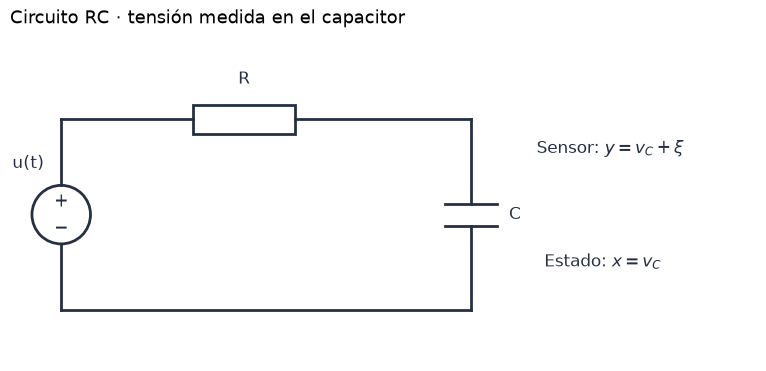

In [23]:
system_diagram("RC")

A = [[0.9]] B = [[0.1]]


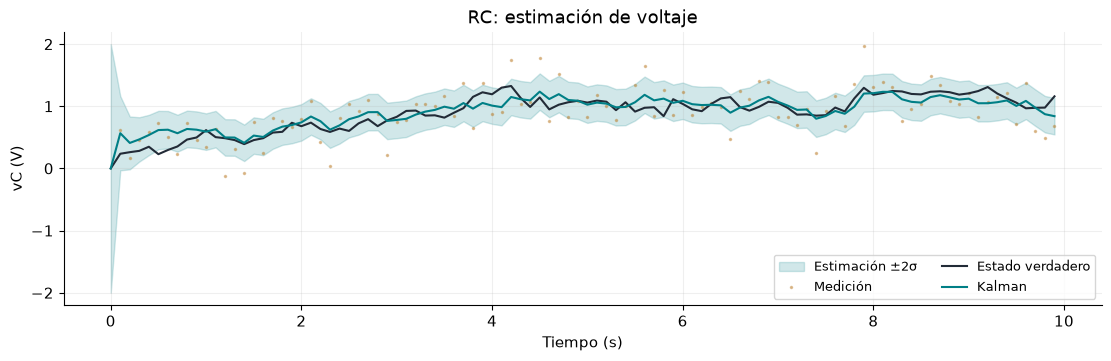

,Estado (unidad),RMSE medición,RMSE Kalman
0,vC (V),0.30394,0.13431


In [24]:
R_ohm, C_farad, T_rc, N_rc = 1.0, 1.0, 0.1, 100
Ac_rc = np.array([[-1/(R_ohm*C_farad)]])
Bc_rc = np.array([[1/(R_ohm*C_farad)]])
A_rc, B_rc = discretize(Ac_rc, Bc_rc, T_rc)
C_rc = np.array([[1.]])
Qv_rc, Qxi_rc = np.array([[0.01]]), np.array([[0.1]])
U_rc = np.ones((N_rc, 1))
t_rc = np.arange(N_rc)*T_rc
X_rc, Y_rc = simulate(A_rc, B_rc, C_rc, Qv_rc, Qxi_rc, U_rc, np.zeros(1), seed=11)
res_rc = kalman(A_rc, B_rc, C_rc, Qv_rc, Qxi_rc, U_rc, Y_rc, np.zeros(1), np.eye(1))
print("A =", A_rc, "B =", B_rc)
table_rc = plot_result("RC: estimación de voltaje", t_rc, X_rc, Y_rc, res_rc,
                       ["vC (V)"], [0])

### 4.1 Una iteración numérica con las ocho ecuaciones

Usamos Euler: $A=0.9$, $B=0.1$, $C=1$, $Q_v=0.01$, $Q_\xi=0.1$, $\hat x_0=0$, $P_0=1$, $u_0=1$. La **medición ilustrativa** es $y_1=0.4$ V; no es necesariamente la primera muestra aleatoria de la simulación.

1. $\hat x_1^-=0.9(0)+0.1(1)=0.1$ V.
2. $\hat y_1=1(0.1)=0.1$ V.
3. $P_1^-=0.9^2(1)+0.01=0.82$ V².
4. $P_1^y=1(0.82)1+0.1=0.92$ V².
5. $P_1^{xy}=0.82(1)=0.82$ V².
6. $L_1^*=0.82/0.92\approx0.89130$.
7. $\hat x_1=0.1+0.89130(0.4-0.1)\approx0.36739$ V.
8. $P_1^*=0.82-(0.89130)^2(0.92)\approx0.08913$ V².

Para predecir el instante 2, se toma $P_1=P_1^*$.

,Ecuación,Variable,Valor
0,1,x_minus,0.100000
1,2,y_hat,0.100000
2,3,P_minus,0.820000
3,4,Py,0.920000
4,5,Pxy,0.820000
5,6,L_star,0.891304
6,7,xhat_next,0.367391
7,8,P_star_next,0.089130


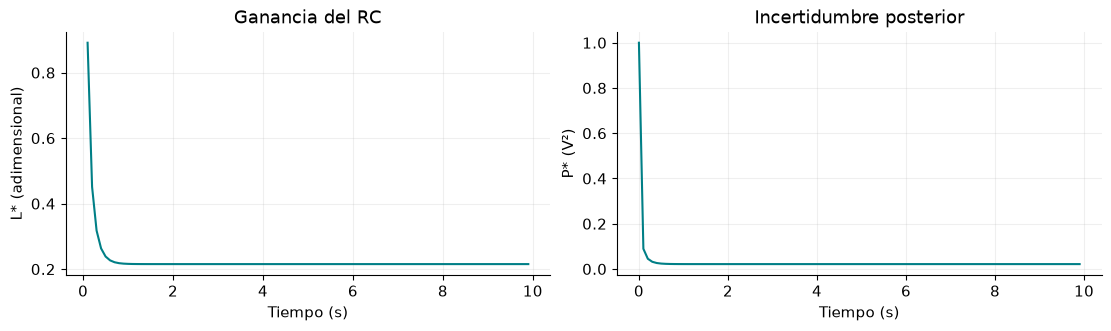

In [41]:
# Una iteración escalar.
x_minus = 0.9*0.0 + 0.1*1.0         # 1
y_hat = 1.0*x_minus                 # 2
P_minus = 0.9*1.0*0.9 + 0.01        # 3
Py = 1.0*P_minus*1.0 + 0.1          # 4
Pxy = P_minus*1.0                   # 5
L_star = Pxy/Py                    # 6
xhat_next = x_minus + L_star*(0.4-y_hat)  # 7
P_star_next = P_minus - L_star*Py*L_star  # 8
display(pd.DataFrame({"Ecuación": range(1,9),
    "Variable": ["x_minus", "y_hat", "P_minus", "Py", "Pxy", "L_star", "xhat_next", "P_star_next"],
    "Valor": [x_minus, y_hat, P_minus, Py, Pxy, L_star, xhat_next, P_star_next]}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), layout="constrained")
axes[0].plot(t_rc[1:], res_rc["L_star"][1:,0,0], color="#007f86")
axes[0].set(title="Ganancia del RC", xlabel="Tiempo (s)", ylabel="L* (adimensional)")
axes[1].plot(t_rc, res_rc["P_star"][:,0,0], color="#007f86")
axes[1].set(title="Incertidumbre posterior", xlabel="Tiempo (s)", ylabel="P* (V²)")
plt.show()

## 5. Ejemplo 2: estimar voltaje y corriente midiendo solo voltaje

### ¿Qué circuito corresponde a la matriz del segundo script?
La interpretación compatible es **un inductor en serie entre la fuente y un nodo con resistencia y capacitor en paralelo**. No es un RLC puramente en serie. La topología se infiere de las ecuaciones del archivo.

En el nodo de salida, $i_L=i_R+i_C=v_C/R_{\Omega}+C_f\dot v_C$. En el inductor, con corriente hacia el nodo, $L_h\dot i_L=u-v_C$. Por tanto:
$$\dot v_C=-\frac{v_C}{R_{\Omega}C_f}+\frac{i_L}{C_f},\qquad
\dot i_L=-\frac{v_C}{L_h}+\frac{u}{L_h}.$$
Con $x=[v_C,i_L]^T$:
$$A_c=\begin{bmatrix}-1/(R_{\Omega}C_f)&1/C_f\\-1/L_h&0\end{bmatrix},\quad
B_c=\begin{bmatrix}0\\1/L_h\end{bmatrix},\quad C=\begin{bmatrix}1&0\end{bmatrix}.$$
Euler reproduce exactamente la estructura de `Ad` y `Bd` del segundo archivo.

Referencias físicas: [OpenStax — reglas de Kirchhoff](https://openstax.org/books/university-physics-volume-2/pages/10-3-kirchhoffs-rules) y [relación voltaje-corriente de un inductor](https://openstax.org/books/university-physics-volume-2/pages/14-2-self-inductance-and-inductors). 

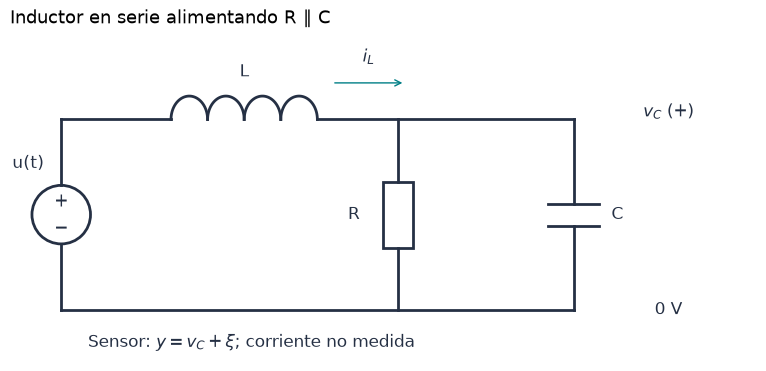

In [26]:
system_diagram("RLC")

A = [[ 0.99  0.01]
 [-0.01  1.  ]] 
B = [[0.  ]
 [0.01]]


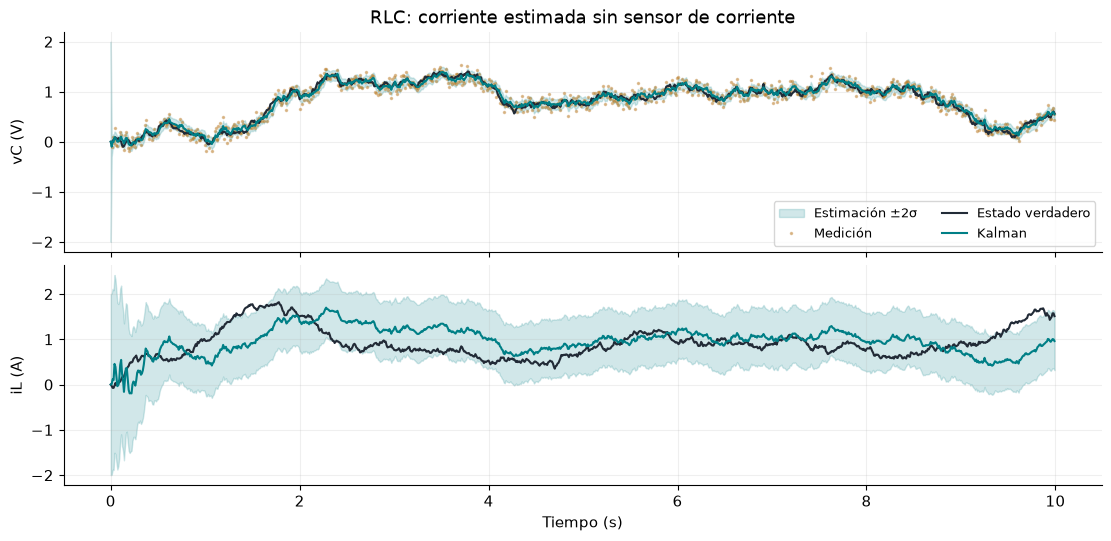

,Estado (unidad),RMSE medición,RMSE Kalman
0,vC (V),0.09771,0.05635
1,iL (A),NaN,0.39325


In [27]:
R_ohm, L_henry, C_farad = 1.0, 1.0, 1.0
T_rlc, N_rlc = 0.01, 1000
Ac_rlc = np.array([[-1/(R_ohm*C_farad), 1/C_farad], [-1/L_henry, 0.]])
Bc_rlc = np.array([[0.], [1/L_henry]])
A_rlc, B_rlc = discretize(Ac_rlc, Bc_rlc, T_rlc)
C_rlc = np.array([[1., 0.]])
Qv_rlc = np.diag([0.001, 0.001])  # V² y A² por paso, respectivamente
Qxi_rlc = np.array([[0.01]])       # V²
U_rlc = np.ones((N_rlc, 1))
t_rlc = np.arange(N_rlc)*T_rlc
X_rlc, Y_rlc = simulate(A_rlc, B_rlc, C_rlc, Qv_rlc, Qxi_rlc, U_rlc, np.zeros(2), seed=22)
res_rlc = kalman(A_rlc, B_rlc, C_rlc, Qv_rlc, Qxi_rlc,
                 U_rlc, Y_rlc, np.zeros(2), np.eye(2))
print("A =", A_rlc, "\nB =", B_rlc)
table_rlc = plot_result("RLC: corriente estimada sin sensor de corriente", t_rlc,
                        X_rlc, Y_rlc, res_rlc, ["vC (V)", "iL (A)"], [0])

### 5.1 ¿De dónde sale información sobre la corriente?

La corriente modifica la evolución del voltaje. Por Euler:
$$\mathcal O=\begin{bmatrix}C\\CA\end{bmatrix}
=\begin{bmatrix}1&0\\1-T/(R_{\Omega}C_f)&T/C_f\end{bmatrix}.$$
Como $\det(\mathcal O)=T/C_f\ne0$, ambos estados son observables. Una secuencia de salidas permite reconstruir el estado en el modelo determinista sin ruido; esto no significa reconstrucción exacta bajo ruido.

La segunda componente de la ecuación 7 es
$$\hat i_{L,k+1}=\hat i^-_{L,k+1}+[L^*_{k+1}]_2\left(y_{k+1}-\hat y_{k+1}\right).$$
Aunque $C$ no mida corriente directamente, la covarianza cruzada $P^{xy}_{k+1}$ permite una ganancia no nula para ella. Esa componente de $L^*$ tiene unidades A/V, no es un porcentaje de confianza.

Matriz de observabilidad:
 [[1.   0.  ]
 [0.99 0.01]]
Rango: 2 de 2


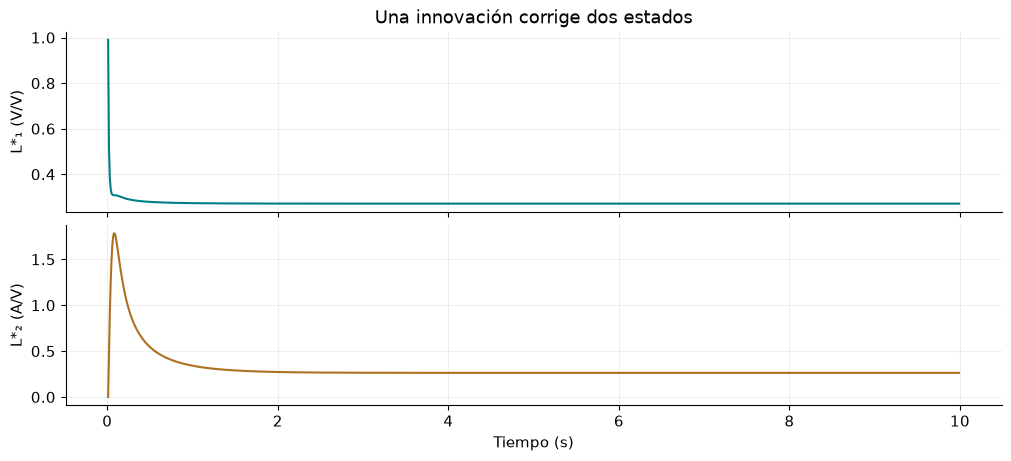

In [28]:
O_rlc = observability_matrix(A_rlc, C_rlc)
print("Matriz de observabilidad:\n", O_rlc)
print("Rango:", np.linalg.matrix_rank(O_rlc), "de", A_rlc.shape[0])
fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True, layout="constrained")
axes[0].plot(t_rlc[1:], res_rlc["L_star"][1:, 0, 0], color="#007f86")
axes[0].set_ylabel("L*₁ (V/V)")
axes[1].plot(t_rlc[1:], res_rlc["L_star"][1:, 1, 0], color="#ad7020")
axes[1].set(xlabel="Tiempo (s)", ylabel="L*₂ (A/V)")
axes[0].set_title("Una innovación corrige dos estados")
plt.show()

## 6. Ejemplo 3: dos masas, dos sensores, cuatro estados

### Origen del modelo mecánico
La masa $m_1$ está unida a una pared por un resorte $k_1$ y un amortiguador $b$ en paralelo. El resorte $k_2$ une ambas masas. La fuerza $u$ actúa sobre $m_2$. Los desplazamientos $q_1,q_2$ se miden desde el equilibrio y son positivos hacia la derecha. No hay otro rozamiento.

Aplicando $\sum F=m\ddot q$, fuerzas elásticas y amortiguamiento viscoso:
$$m_1\ddot q_1=-k_1q_1-b\dot q_1+k_2(q_2-q_1),$$
$$m_2\ddot q_2=-k_2(q_2-q_1)+u.$$
Para $m_1=m_2=m$ y $x=[q_1,\dot q_1,q_2,\dot q_2]^T$:
$$A_c=\begin{bmatrix}
0&1&0&0\\
-(k_1+k_2)/m&-b/m&k_2/m&0\\
0&0&0&1\\
k_2/m&0&-k_2/m&0
\end{bmatrix},\quad B_c=\begin{bmatrix}0\\0\\0\\1/m\end{bmatrix}.$$
Dos sensores de posición dan
$$C=\begin{bmatrix}1&0&0&0\\0&0&1&0\end{bmatrix}.$$

Fundamento externo: [OpenStax — movimiento masa-resorte y segunda ley de Newton](https://openstax.org/books/university-physics-volume-1/pages/15-1-simple-harmonic-motion). 

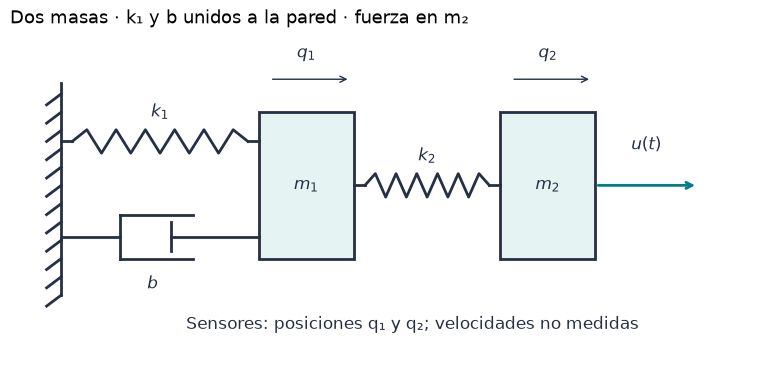

In [29]:
system_diagram("MASSES")

### 6.1 Dos sensores: una distinción importante en el ruido

Para el ejercicio base elegimos explícitamente **sensores independientes**:
$$Q_\xi=\begin{bmatrix}0.01&0\\0&0.01\end{bmatrix}\ \mathrm m^2.$$
Generamos entonces un vector gaussiano de dimensión dos. Cada sensor tiene desviación estándar $\sqrt{0.01}=0.1$ m. 

Rango de observabilidad: 4 / 4
Radio espectral de A: 0.9719552909465251


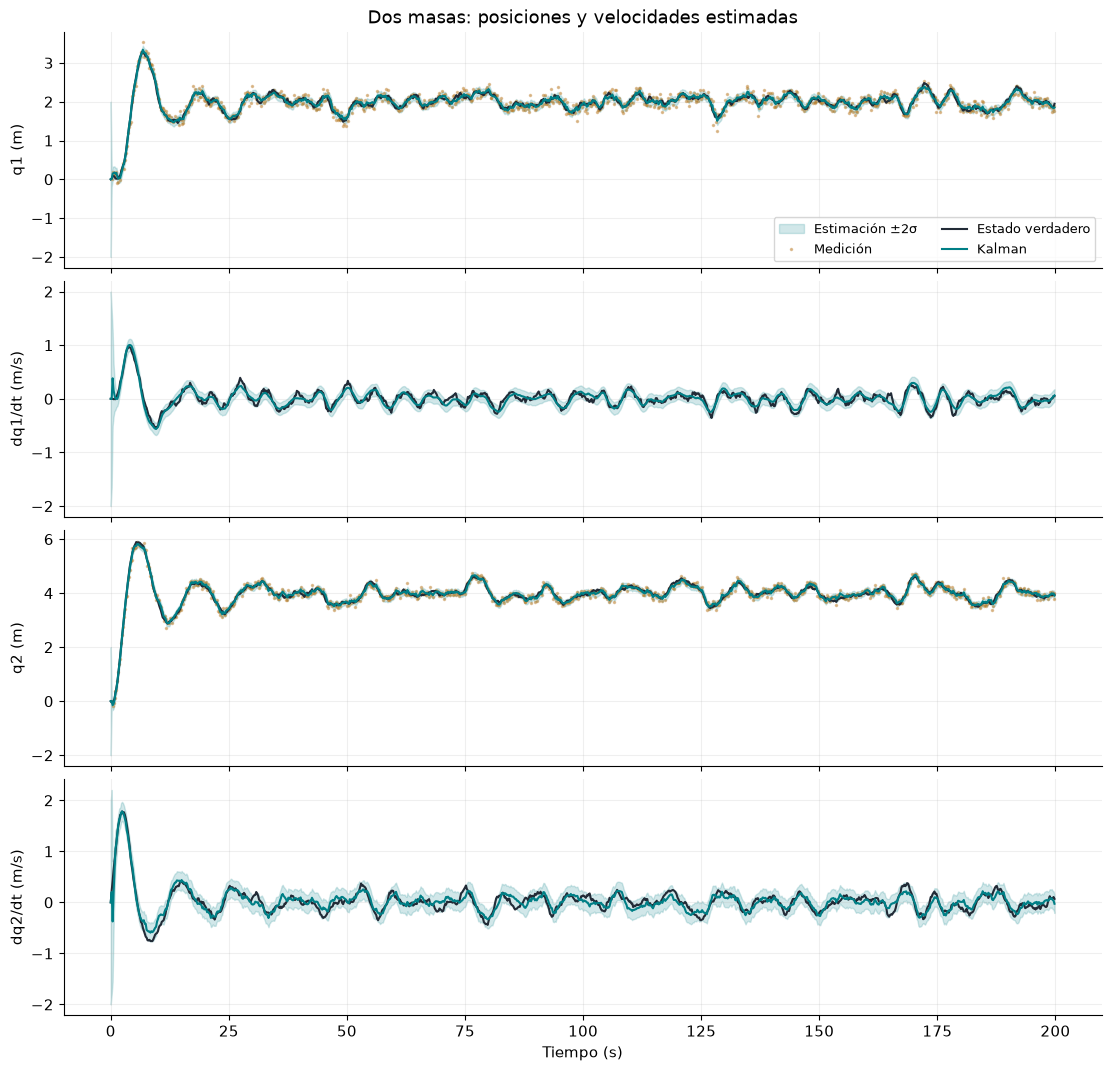

,Estado (unidad),RMSE medición,RMSE Kalman
0,q1 (m),0.09949,0.04959
1,dq1/dt (m/s),NaN,0.05943
2,q2 (m),0.09815,0.06220
3,dq2/dt (m/s),NaN,0.09227


In [30]:
m, b, k1, k2 = 1.0, 1.0, 0.5, 0.5
T_mass, N_mass = 0.2, 1000
Ac_mass = np.array([[0.,1.,0.,0.],
                    [-(k1+k2)/m,-b/m,k2/m,0.],
                    [0.,0.,0.,1.],
                    [k2/m,0.,-k2/m,0.]])
Bc_mass = np.array([[0.], [0.], [0.], [1/m]])
A_mass, B_mass = discretize(Ac_mass, Bc_mass, T_mass)
C_mass = np.array([[1.,0.,0.,0.], [0.,0.,1.,0.]])
Qv_mass = np.diag([0.001]*4)  # unidades: m², (m/s)², m², (m/s)²
Qxi_mass = np.diag([0.01, 0.01])
U_mass = np.ones((N_mass, 1))
t_mass = np.arange(N_mass)*T_mass
X_mass, Y_mass = simulate(A_mass, B_mass, C_mass, Qv_mass, Qxi_mass,
                          U_mass, np.zeros(4), seed=33)
res_mass = kalman(A_mass, B_mass, C_mass, Qv_mass, Qxi_mass,
                  U_mass, Y_mass, np.zeros(4), np.eye(4))
print("Rango de observabilidad:", np.linalg.matrix_rank(observability_matrix(A_mass, C_mass)), "/ 4")
print("Radio espectral de A:", np.max(np.abs(np.linalg.eigvals(A_mass))))
table_mass = plot_result("Dos masas: posiciones y velocidades estimadas", t_mass,
                         X_mass, Y_mass, res_mass,
                         ["q1 (m)", "dq1/dt (m/s)", "q2 (m)", "dq2/dt (m/s)"], [0, 2])

## 7. ¿Cómo elegir Qᵥ, Qξ y P₀?

- **$Q_\xi$:** covarianza del sensor. Si su desviación estándar es $\sigma$, la varianza es $\sigma^2$. Coloca varianzas en la diagonal y covarianzas conocidas fuera de ella. Las mediciones repetidas de una cantidad constante permiten una primera estimación, tras revisar sesgos y autocorrelación.
- **$Q_v$:** incertidumbre en la evolución del estado durante un intervalo. Puede representar perturbaciones no modeladas; no es ruido que se suma a la medición. Una mala dinámica determinista no siempre se corrige aumentando esta matriz.
- **$P_0$:** incertidumbre inicial. Si conoces la posición mejor que la velocidad, usa varianzas distintas. `eye(n)` es solo una inicialización didáctica en las unidades escogidas.

Los `Qv=0.001*I` son covarianzas discretas asumidas, no deducidas de resistencias, masas o resortes. Diagonales iguales para estados con diferentes unidades no implican igual incertidumbre física.

Si $v_k=G\eta_k$ y $\operatorname{cov}(\eta_k)=\Sigma_\eta$, entonces
$$Q_v=G\Sigma_\eta G^\top.$$
Una fuerza aleatoria constante por intervalo aplicada a $m_2$ entra por la misma matriz discreta que la entrada conocida:
$$Q_v=B\sigma_f^2 B^\top.$$

Para ruido blanco continuo con intensidad $Q_c$ y matriz de entrada $G_c$, la conversión es distinta:
$$Q_v=\int_0^T e^{A_c\tau}G_cQ_cG_c^\top e^{A_c^\top\tau}\,d\tau.$$
Cambiar T manteniendo el mismo Qv generalmente cambia el modelo estocástico. En los ejercicios básicos conservamos las covarianzas por paso de los archivos originales.

### 7.1 Experimento: el filtro supone un Qξ equivocado

Mantendremos **exactamente las mismas mediciones y trayectoria** del RC. Solo cambiaremos el valor de Qξ dentro del filtro. Así se compara la confianza del estimador, no sensores o ruidos distintos.

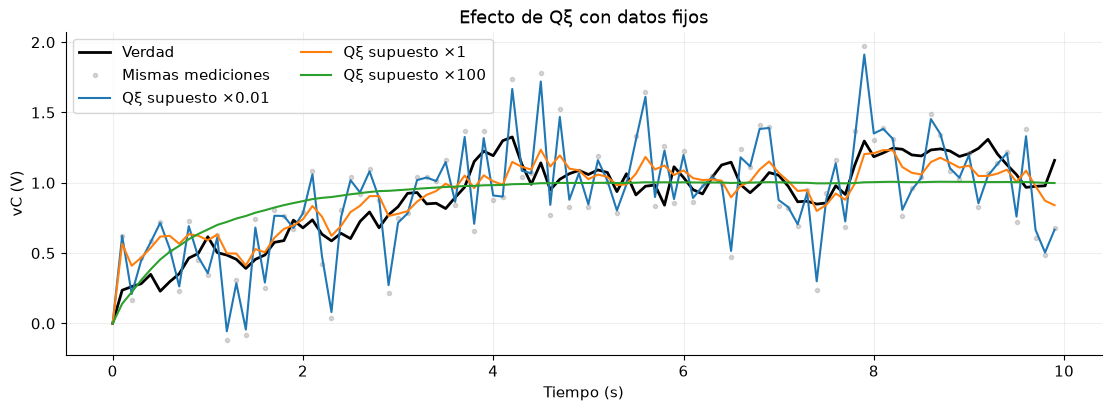

,Factor Qξ,RMSE (V),L* final
0,0.01,0.27972,0.91483
1,1.00,0.13431,0.21533
2,100.00,0.17177,0.00512


In [31]:
fig, ax = plt.subplots(figsize=(11,4), layout="constrained")
ax.plot(t_rc, X_rc[:,0], color="black", lw=2, label="Verdad")
ax.plot(t_rc[1:], Y_rc[1:,0], '.', color="gray", alpha=.3, label="Mismas mediciones")
sensitivity = []
for factor in [0.01, 1., 100.]:
    r = kalman(A_rc, B_rc, C_rc, Qv_rc, factor*Qxi_rc, U_rc, Y_rc, np.zeros(1), np.eye(1))
    ax.plot(t_rc, r["xhat"][:,0], label=f"Qξ supuesto ×{factor:g}")
    sensitivity.append({"Factor Qξ": factor,
                        "RMSE (V)": np.sqrt(np.mean((r["xhat"][1:,0]-X_rc[1:,0])**2)),
                        "L* final": r["L_star"][-1,0,0]})
ax.set(title="Efecto de Qξ con datos fijos", xlabel="Tiempo (s)", ylabel="vC (V)")
ax.legend(ncol=2); plt.show()
display(pd.DataFrame(sensitivity).round(5))

En el RC, Qξ demasiado pequeño hace que el filtro siga más las mediciones ruidosas; Qξ demasiado grande lo hace depender más del modelo y puede ocultar perturbaciones reales. Un RMSE menor en una única realización no demuestra optimalidad: conviene repetir con múltiples semillas y valorar también incertidumbre e innovaciones.

### 7.2 Diagnóstico sin conocer la verdad: innovación

En el modelo bien especificado, $\nu_{k+1}=y_{k+1}-\hat y_{k+1}$ tiene media cero, covarianza $P^y_{k+1}$ y es blanca. En el caso escalar:
$$\tilde\nu_{k+1}=\frac{y_{k+1}-\hat y_{k+1}}{\sqrt{P^y_{k+1}}}.$$
Esperamos media cercana a cero y varianza cercana a uno, con variabilidad de muestreo. Mostramos su autocorrelación omitiendo el arranque. El diagnóstico puede revelar sesgos o estructura temporal, pero no identifica por sí solo qué parámetro está mal.

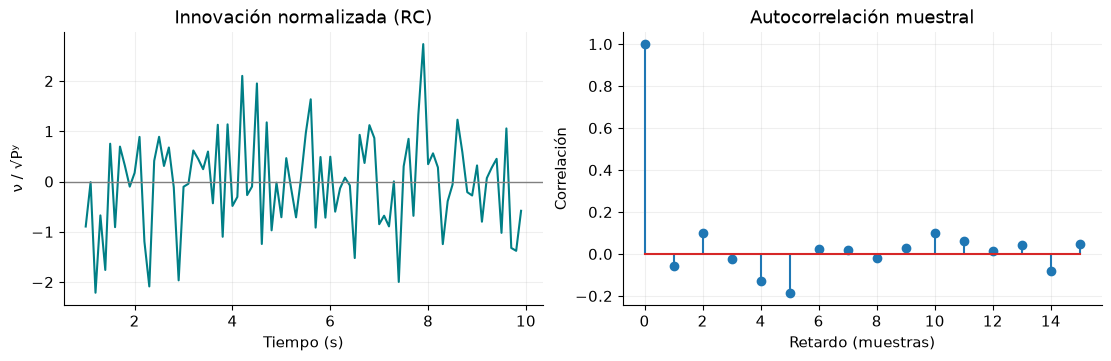

Media: -0.028; varianza muestral: 0.909


In [32]:
normalized = res_rc["innovation"][10:,0] / np.sqrt(res_rc["Py"][10:,0,0])
centered = normalized-normalized.mean()
acf = np.correlate(centered, centered, mode="full")[len(centered)-1:]
acf = acf[:16]/acf[0]
fig, axes = plt.subplots(1,2,figsize=(11,3.5),layout="constrained")
axes[0].plot(t_rc[10:], normalized, color="#007f86")
axes[0].axhline(0,color="gray",lw=1)
axes[0].set(title="Innovación normalizada (RC)",xlabel="Tiempo (s)",ylabel="ν / √Pʸ")
axes[1].stem(np.arange(len(acf)), acf)
axes[1].set(title="Autocorrelación muestral",xlabel="Retardo (muestras)",ylabel="Correlación")
plt.show()
print(f"Media: {normalized.mean():.3f}; varianza muestral: {normalized.var(ddof=1):.3f}")

## Referencias y siguiente lectura

- **RC:** [OpenStax, University Physics Vol. 2, §10.5](https://openstax.org/books/university-physics-volume-2/pages/10-5-rc-circuits). Balance de voltajes y carga/descarga de un capacitor.
- **RLC:** [OpenStax, §10.3, reglas de Kirchhoff](https://openstax.org/books/university-physics-volume-2/pages/10-3-kirchhoffs-rules) y [§14.2, inductores](https://openstax.org/books/university-physics-volume-2/pages/14-2-self-inductance-and-inductors). Fundamentos para reconstruir la topología del segundo archivo.
- **Mecánica:** [OpenStax, University Physics Vol. 1, §15.1](https://openstax.org/books/university-physics-volume-1/pages/15-1-simple-harmonic-motion). Segunda ley de Newton y fuerza de un resorte.
- **Discretización:** [documentación oficial de SciPy, cont2discrete](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cont2discrete.html). Métodos Euler y ZOH.
- **Kalman:** [documentación de FilterPy](https://filterpy.readthedocs.io/en/latest/kalman/KalmanFilter.html) y [su implementación](https://filterpy.readthedocs.io/en/latest/_modules/filterpy/kalman/kalman_filter.html). Referencia complementaria; usa otra notación. 
- **Para profundizar:** Roger R. Labbe, [Kalman and Bayesian Filters in Python](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/06-Multivariate-Kalman-Filters.ipynb), capítulo 6, filtro multivariable.